## Notebook to examine data from Gurnani & Silver, 2021

### 1) Import required Python modules

Note: you can use `pip install -r requirements.txt` to install all the required packages

In [1]:
# Check all important packages can be imported
import matplotlib.pyplot as plt
import mat73
import pynwb
import sys

### 2) Load in the data from the original MATLAB format

In [2]:

sys.path.append("../python") # Add the path to the python directory
from LoadMatData import load_mat_file

original_experiment_id = "HG13__180827_12_28_17"

mat_file = f"../data/{original_experiment_id}.mat"

# Load the .mat file
neuron_df_f, neuron_times, speed, whisker_motion_index, state, pca_dff, puff_events, = load_mat_file(mat_file)


Loading data from: ../data/HG13__180827_12_28_17.mat
Variables in the .mat file: dict_keys(['allAnalysed', 'allData', 'allEvents'])
Neuron data (shape: (41, 14280))
Neuron times data (shape: (41, 14280))
Speed data (shape: (2, 186450))
Whisker motion index data (shape: (2, 120361))
State data (shape: (2, 120361))
PCA of dF/F data (shape: (9, 14280))
Puff event data (shape: (2, 20))


In [30]:
print(neuron_times)

[[  1000.46603878   1028.50998878   1056.55393878 ... 402355.56736545
  402383.61131545 402411.65526545]
 [  1001.16704211   1029.21099211   1057.25494211 ... 402356.26836877
  402384.31231877 402412.35626877]
 [  1001.82652727   1029.87047727   1057.91442727 ... 402356.92785394
  402384.97180394 402413.01575394]
 ...
 [  1026.44428209   1054.48823209   1082.53218209 ... 402381.54560876
  402409.58955876 402437.63350876]
 [  1027.13694415   1055.18089415   1083.22484415 ... 402382.23827082
  402410.28222082 402438.32617082]
 [  1027.82927667   1055.87322667   1083.91717667 ... 402382.93060333
  402410.97455333 402439.01850333]]


### 3) Generate some plots of the contained data

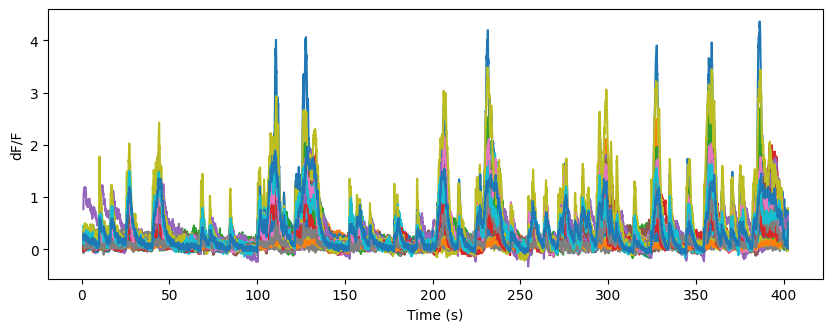

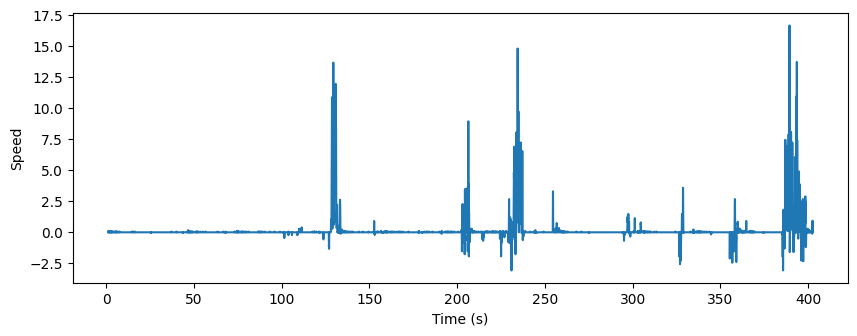

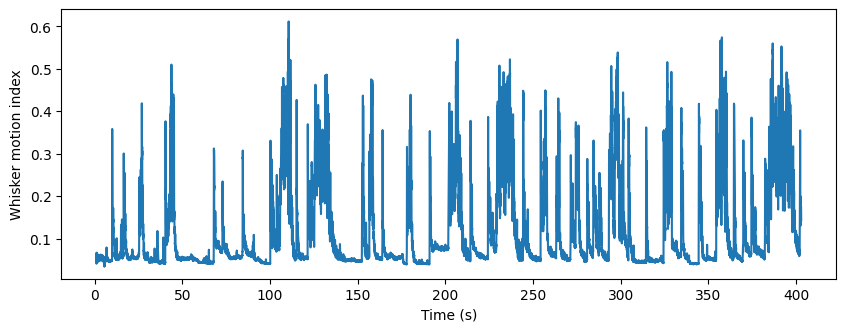

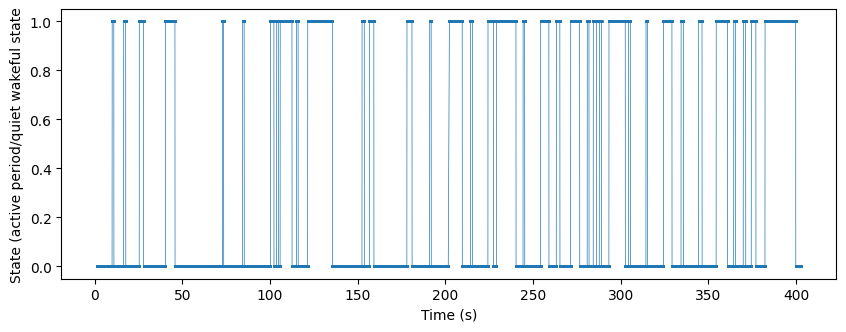

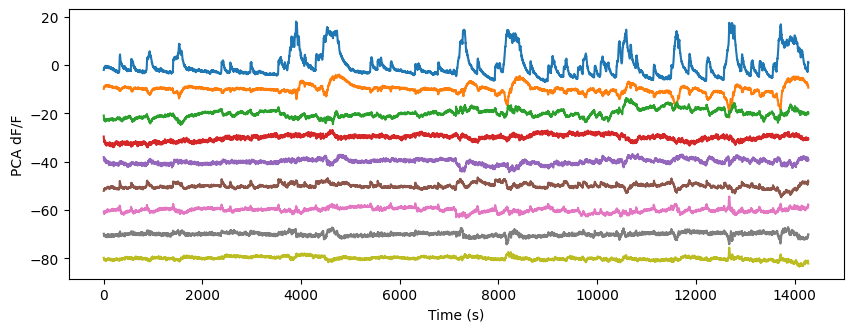

In [3]:
figsize=(10, 3.5)
plt.figure(figsize=figsize)

plt.xlabel("Time (s)")
plt.ylabel("dF/F")

for index in range(len(neuron_df_f)):
    plt.plot([t / 1000 for t in neuron_times[index]], neuron_df_f[index])

plt.figure(figsize=figsize)
plt.xlabel("Time (s)")
plt.ylabel("Speed")
plt.plot([t / 1000 for t in speed[0]], speed[1])

plt.figure(figsize=figsize)
plt.xlabel("Time (s)")
plt.ylabel("Whisker motion index")
plt.plot([t / 1000 for t in whisker_motion_index[0]], whisker_motion_index[1])

plt.figure(figsize=figsize)
plt.xlabel("Time (s)")
plt.ylabel("State (active period/quiet wakeful state")
plt.plot(
    [t / 1000 for t in state[0]], state[1], linewidth=0.5, marker=".", markersize=2
)

plt.figure(figsize=figsize)

plt.xlabel("Time (s)")
plt.ylabel("PCA dF/F")

for index in range(len(pca_dff)):
    plt.plot(pca_dff[index] + index * -10, label=f"PC {index+1}")

### 4) Generate a figure similar to Figure 1D in paper

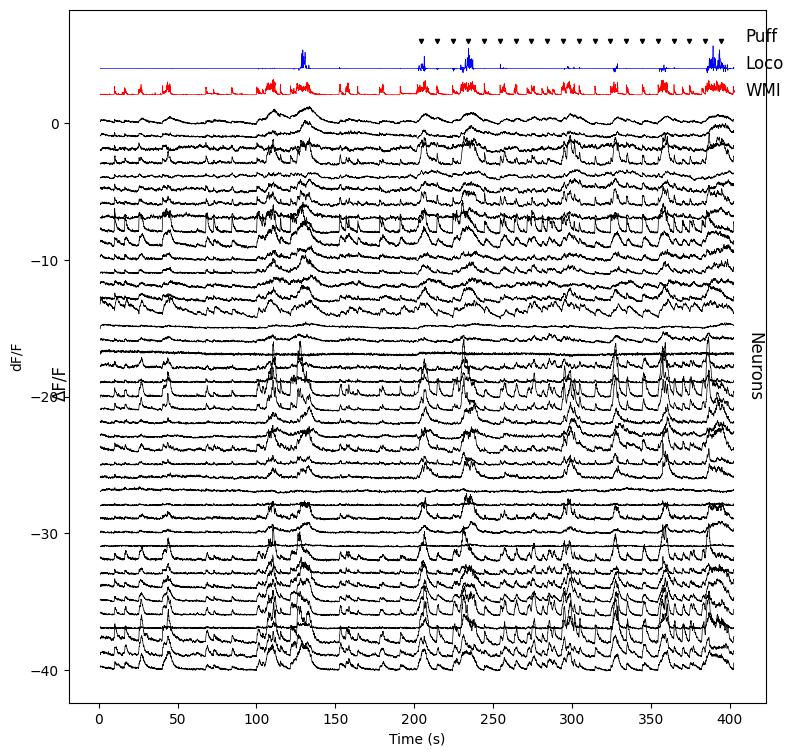

In [26]:
fig, ax = plt.subplots(figsize=(9, 9))

plt.xlabel("Time (s)")
plt.ylabel("dF/F")

#ax.set_axis_off()

offset = 1
for index in range(len(neuron_df_f)):
    plt.plot(
        [t / 1000 for t in neuron_times[index]],
        neuron_df_f[index] - index*offset,
        color="black",
        linewidth=0.5,
    )

plt.text(
    -30,
    -20,
    "ΔF/F",
    rotation=90,
    fontsize=12,
)
plt.text(
    410,
    -20,
    "Neurons",
    rotation=270,
    fontsize=12,
)

scale_wmi = 2
plt.plot([t / 1000 for t in whisker_motion_index[0]], whisker_motion_index[1]*scale_wmi+ 2*offset, color="red", linewidth=0.5)

plt.text(
    410,
    2,
    "WMI",
    fontsize=12,
)

scale_speed = 0.1
plt.plot([t / 1000 for t in speed[0]], speed[1]*scale_speed+ 4*offset, color="blue", linewidth=0.5)

plt.text(
    410,
    4,
    "Loco",
    fontsize=12,
)

if len(puff_events) > 0:
    for e in puff_events[0]:
        #print("Adding puff event at time %s" % (e / 1000))
        plt.plot(e / 1000, 6*offset, color="black", linestyle=None, marker="v", markersize=3)


plt.text(
    410,
    6,
    "Puff",
    fontsize=12,
)

plt.savefig(f"../data/Fig1D_{original_experiment_id}.png", dpi=300, bbox_inches="tight")

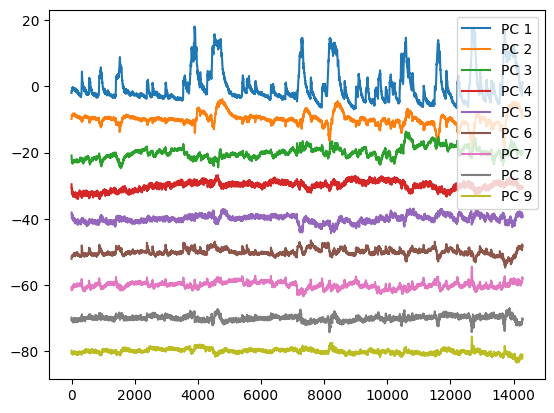

In [17]:
#neuron_df_f, neuron_times, speed, whisker_motion_index, state, pca_dff, puff_events, = load_mat_file(mat_file)
for index in range(len(pca_dff)):
    plt.plot(range(0,14280),pca_dff[index] + index * -10, label=f"PC {index+1}")
plt.legend()


In [ ]:
print(pca_dff[0].shape)
print(t / 1000 for t in whisker_motion_index[0])

(14280,)


AttributeError: 'generator' object has no attribute 'shape'

(1000.0, 1500.0, -2.6, 10.6)

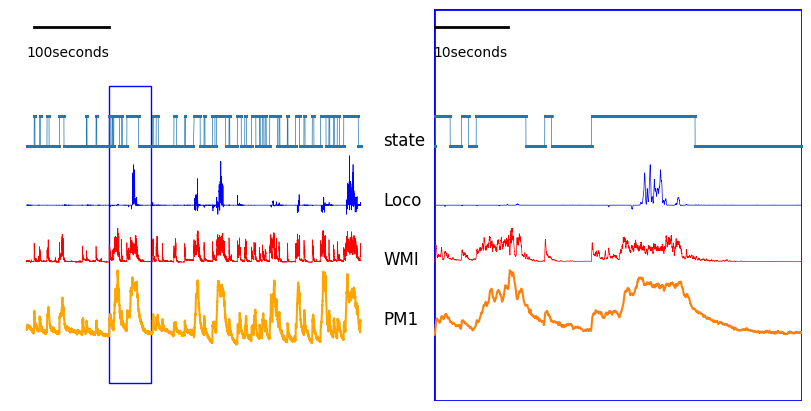

In [105]:
import matplotlib.patches as patches
rect = patches.Rectangle((100, -2), 50, 10,
linewidth=1, edgecolor='b', facecolor='none')
rect2 = patches.Rectangle((100, -2), 50, 10,
linewidth=1, edgecolor='b', facecolor='none')


fig, (ax1, ax2) = plt.subplots(1, 2,
layout='constrained', figsize=(8,4))
ax1.add_patch(rect)
ax1.plot([t / 1000 for t in whisker_motion_index[0]], whisker_motion_index[1]*scale_wmi+ 2*offset, color="red", linewidth=0.5)

ax1.text(
    430,
    2,
    "WMI",
    fontsize=12,
)

ax1.text(
    430,
    6,
    "state",
    fontsize=12,
)

scale_speed = 0.1
ax1.plot([t / 1000 for t in speed[0]], speed[1]*scale_speed+ 4*offset, color="blue", linewidth=0.5)

ax1.text(
    430,
    4,
    "Loco",
    fontsize=12,
)
ax1.text(
    430,
    0,
    "PM1",
    fontsize=12,
)
#x1_norm = x1 / x1[-1]
ax1.plot([t / 1000 for t in neuron_times[0]],(pca_dff[0] + 0 * -10)*0.1, label=f"PC {0+1}",color='orange')
ax1.plot(
    [t / 1000 for t in state[0]], state[1]+6, linewidth=0.5, marker=".", markersize=2
)

ax1.plot([10, 100], [10, 10], color='black', lw=2)  # 线
ax1.text(50, 9, '100seconds', ha='center') 
############
ax2.plot([t / 100 for t in whisker_motion_index[0]], whisker_motion_index[1]*scale_wmi+ 2*offset, color="red", linewidth=0.5)
scale_speed = 0.1
ax2.plot([t / 100 for t in speed[0]], speed[1]*scale_speed+ 4*offset, color="blue", linewidth=0.5)
ax2.plot(
    [t / 100 for t in state[0]], state[1]+6, linewidth=0.5, marker=".", markersize=2
)
ax2.add_patch(rect2)
#x1_norm = x1 / x1[-1]
ax2.plot([t / 100 for t in neuron_times[0]],(pca_dff[0] + 0 * -10)*0.1, label=f"PC {0+1}")
ax2.set_xlim(1000, 1500)
ax2.plot([1000, 1100], [10, 10], color='black', lw=2)  # 线
ax2.text(1050, 9, '10seconds', ha='center')
rect3 = patches.Rectangle(
    (0,0), 1,1, transform=ax2.transAxes,  # 0~1 归一化坐标
    linewidth=2, edgecolor='blue', facecolor='none'
)
ax2.add_patch(rect3) 
ax1.axis('off')
ax2.axis('off')

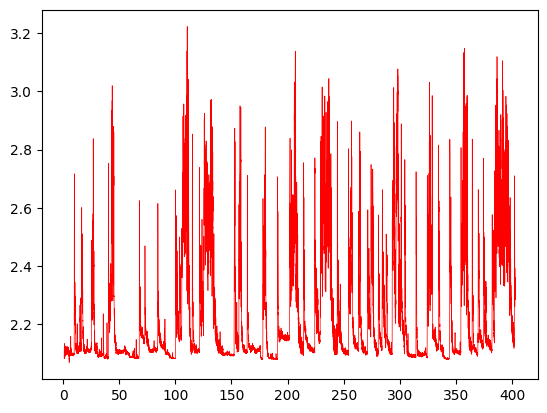

In [29]:
plt.plot([t / 1000 for t in whisker_motion_index[0]], whisker_motion_index[1]*scale_wmi+ 2*offset, color="red", linewidth=0.5)